In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("../dataset/StudentsPerformance_cleaned.csv")

df.head()

,gender,race_ethnicity,parental_education,lunch,test_preparation,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [3]:
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

Rows    : 1000
Columns : 8


In [4]:
cat_features = df.select_dtypes(include="str").columns.tolist()
num_features = df.select_dtypes(exclude="str").columns.tolist()

print("Categorical Features:")
print(cat_features)

print("\nNumerical Features:")
print(num_features)

Categorical Features:
['gender', 'race_ethnicity', 'parental_education', 'lunch', 'test_preparation']

Numerical Features:
['math_score', 'reading_score', 'writing_score']


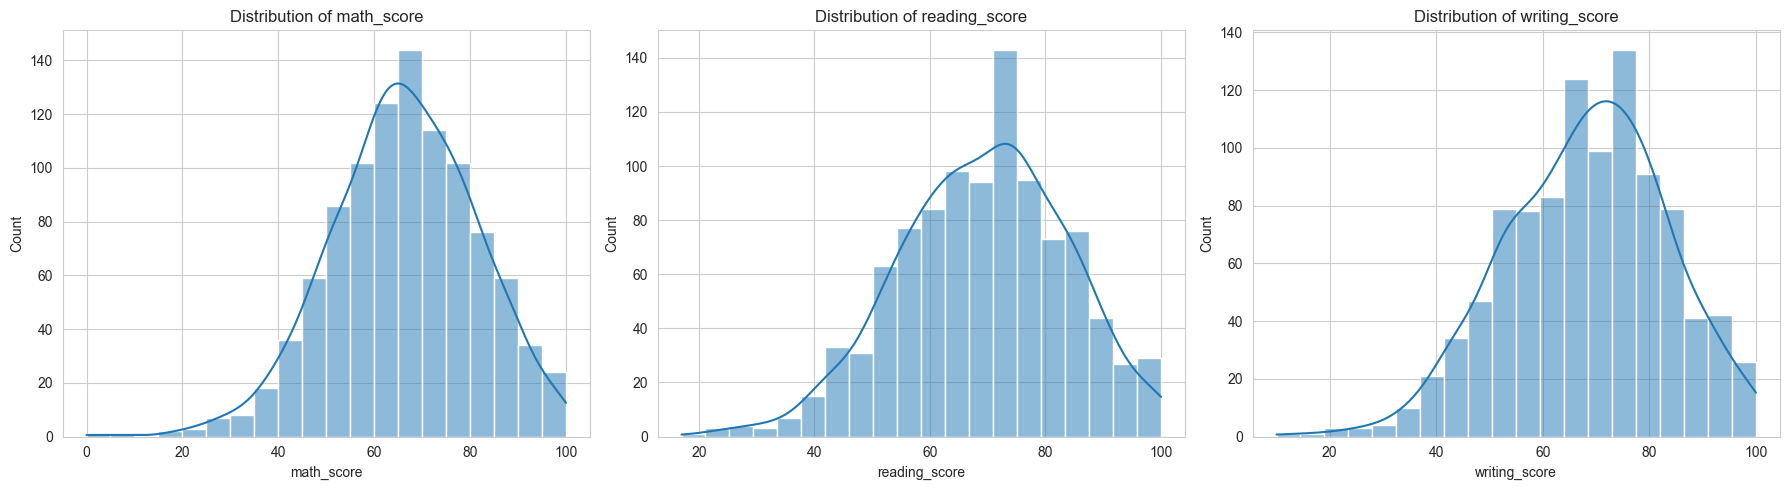

In [5]:
plt.figure(figsize=(18,5))

for i, col in enumerate(num_features):
    plt.subplot(1,3,i+1)
    sns.histplot(df[col], kde=True, bins=20)
    plt.title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

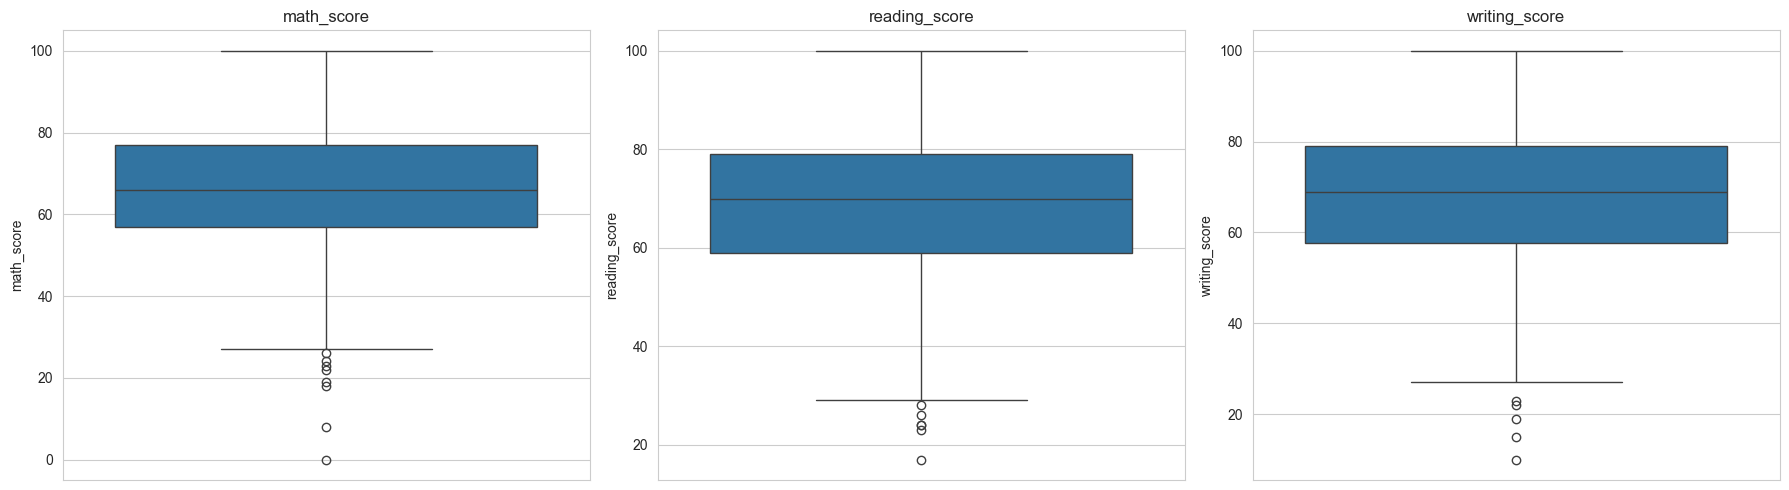

In [6]:
plt.figure(figsize=(18,5))

for i, col in enumerate(num_features):
    plt.subplot(1,3,i+1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

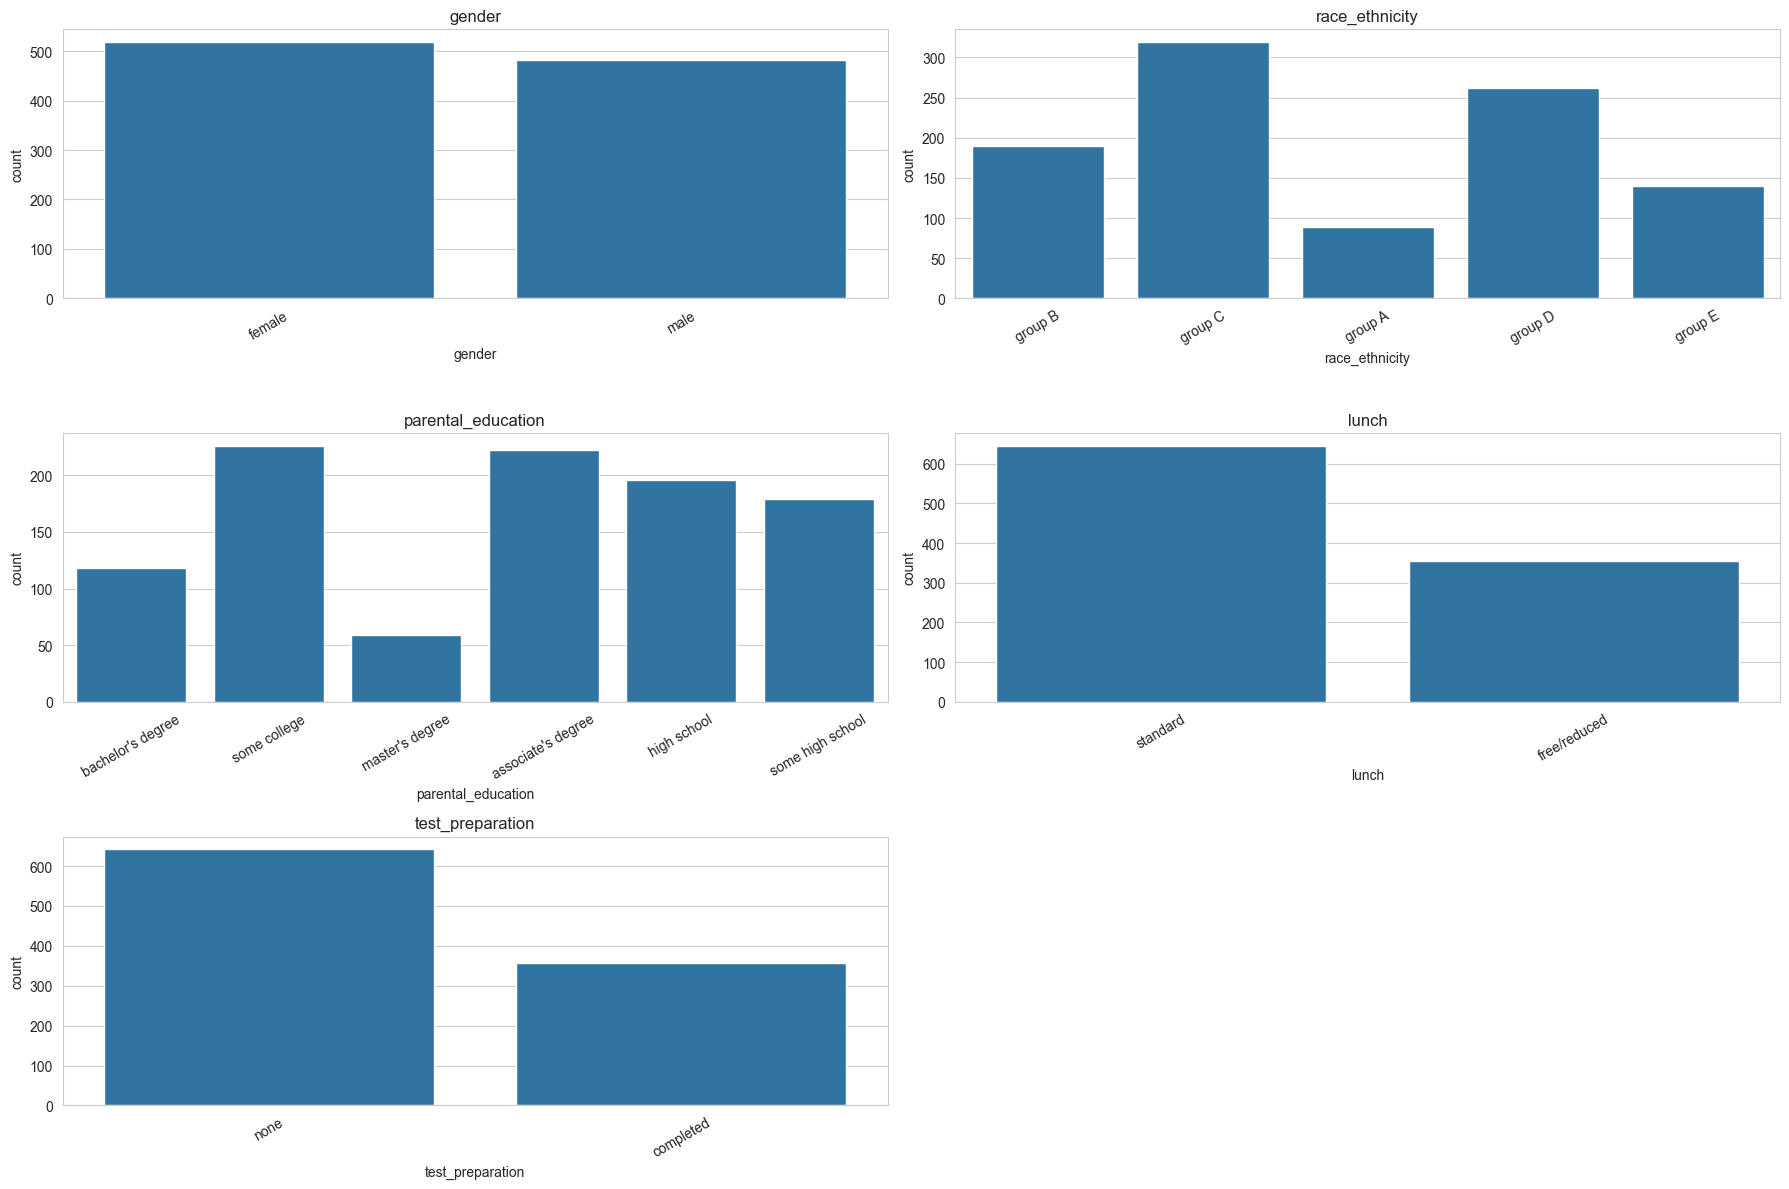

In [7]:
plt.figure(figsize=(18,12))

for i, col in enumerate(cat_features):
    plt.subplot(3,2,i+1)
    sns.countplot(data=df, x=col)
    plt.xticks(rotation=30)
    plt.title(col)

plt.tight_layout()
plt.show()

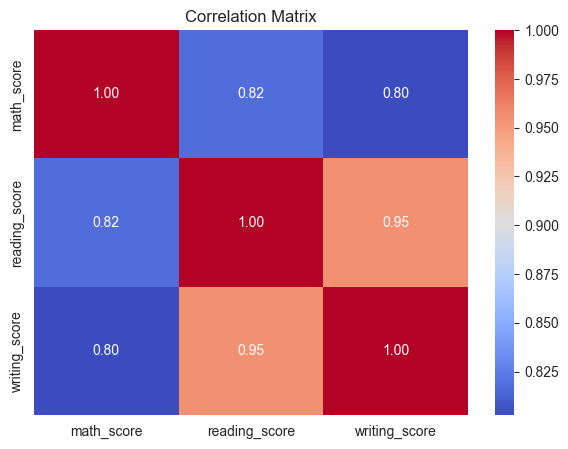

In [8]:
plt.figure(figsize=(7,5))

sns.heatmap(
    df[num_features].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

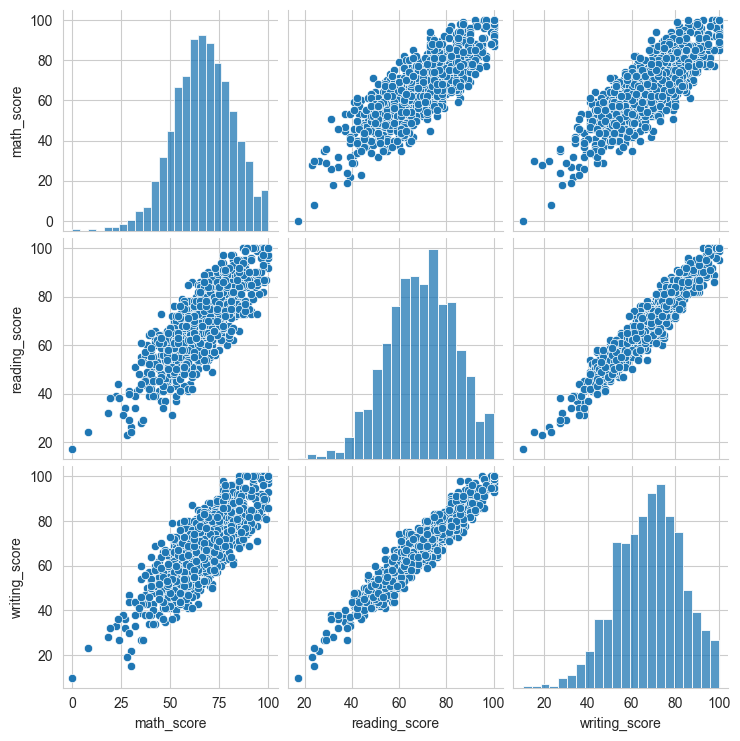

In [9]:
sns.pairplot(df[num_features])

plt.show()

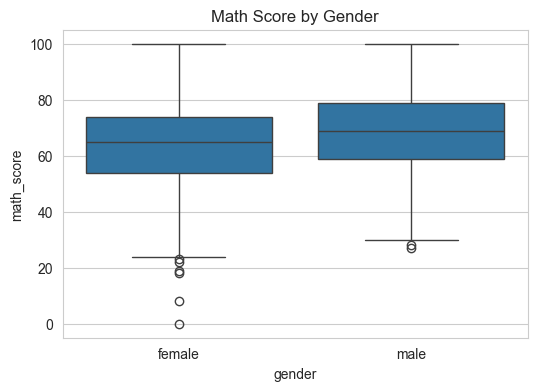

In [ ]:
plt.figure(figsize=(6,4))

sns.boxplot(
    data=df,
    x="gender",
    y="math_score"
)

plt.title("Math Score by Gender")

plt.show()

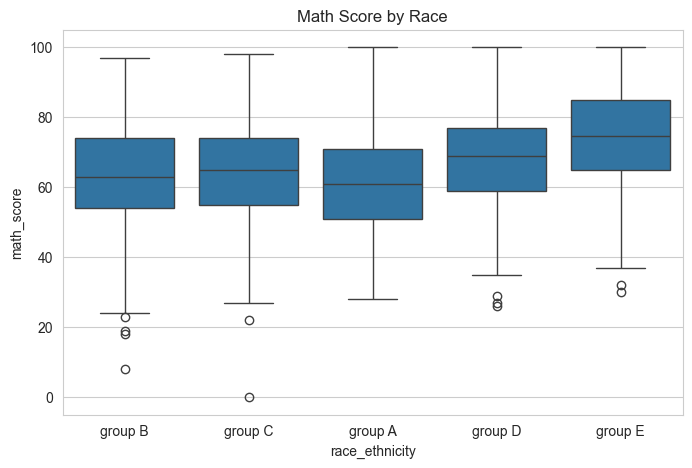

In [11]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="race_ethnicity",
    y="math_score"
)

plt.title("Math Score by Race")

plt.show()

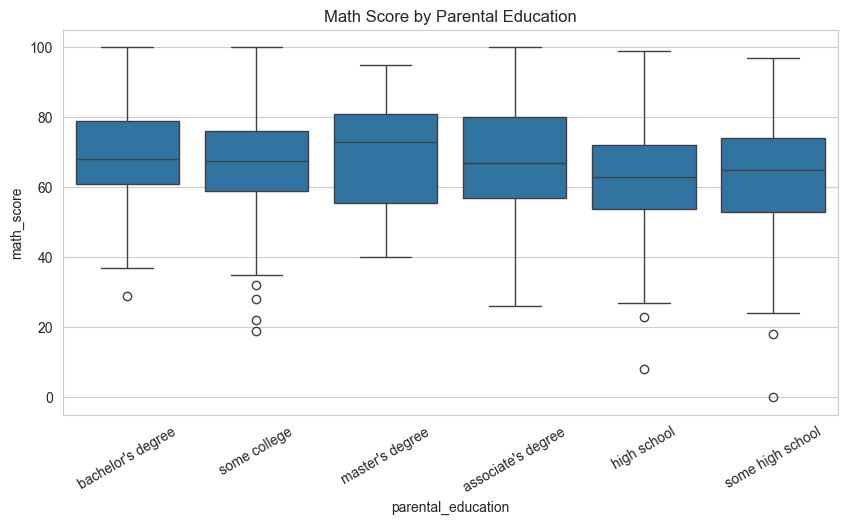

In [12]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x="parental_education",
    y="math_score"
)

plt.xticks(rotation=30)

plt.title("Math Score by Parental Education")

plt.show()

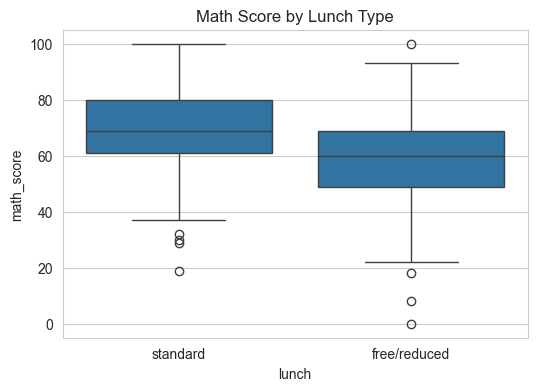

In [13]:
plt.figure(figsize=(6,4))

sns.boxplot(
    data=df,
    x="lunch",
    y="math_score"
)

plt.title("Math Score by Lunch Type")

plt.show()

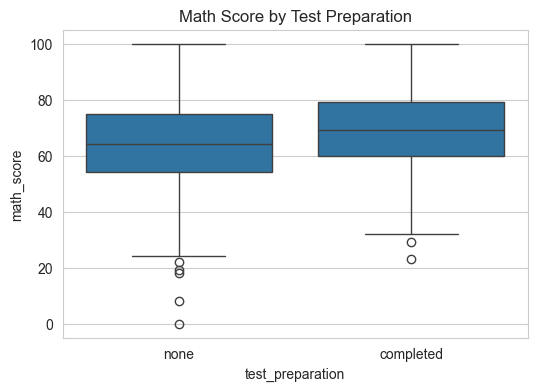

In [14]:
plt.figure(figsize=(6,4))

sns.boxplot(
    data=df,
    x="test_preparation",
    y="math_score"
)

plt.title("Math Score by Test Preparation")

plt.show()

In [15]:
df.groupby("gender")[num_features].mean()

,math_score,reading_score,writing_score
gender,,,
female,63.633205,72.608108,72.467181
male,68.728216,65.473029,63.311203


In [16]:
df.groupby("lunch")[num_features].mean()

,math_score,reading_score,writing_score
lunch,,,
free/reduced,58.921127,64.653521,63.022535
standard,70.034109,71.654264,70.823256


In [17]:
df.groupby("test_preparation")[num_features].mean()

,math_score,reading_score,writing_score
test_preparation,,,
completed,69.695531,73.893855,74.418994
none,64.077882,66.534268,64.504673


In [18]:
df.groupby("parental_education")[num_features].mean()

,math_score,reading_score,writing_score
parental_education,,,
associate's degree,67.882883,70.927928,69.896396
bachelor's degree,69.389831,73.000000,73.381356
high school,62.137755,64.704082,62.448980
master's degree,69.745763,75.372881,75.677966
some college,67.128319,69.460177,68.840708
some high school,63.497207,66.938547,64.888268


In [19]:
corr = df.corr(numeric_only=True)["math_score"].sort_values(ascending=False)
corr

math_score       1.000000
reading_score    0.817580
writing_score    0.802642
Name: math_score, dtype: float64